# PetroFit: 2D Sérsic fitting of M49 (NGC 4472)

M49 is a giant elliptical galaxy in the Virgo cluster — an ideal target for exploring surface brightness profile fitting and the Kormendy relation.

This notebook demonstrates:
1. Load a reduced CCD image and PSF model
2. Source detection and segmentation
3. PSF-convolved 2D Sérsic model fitting
4. Extract physical parameters: $r_e$, $\mu_e$, $n$, ellipticity
5. Non-parametric isophote fitting with `photutils.isophote`

**Data**: T120 (1.2m Newton, OHP), R-band, 60s exposure, 2025-03-17.

In [86]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from astropy.io import fits
from astropy.nddata import CCDData, Cutout2D
from astropy.stats import sigma_clipped_stats
from astropy.modeling import models

import petrofit as pf

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['image.origin'] = 'lower'

## 1. Load the data

In [87]:
import os

# Data bundled with this notebook
DATA_DIR = os.path.join(os.path.dirname(os.getcwd()), 'notebooks', 'data')
# If running from within notebooks/ directory:
if not os.path.exists(DATA_DIR):
    DATA_DIR = 'data'

FRAME = os.path.join(DATA_DIR, 'M49-0004R.fits')
PSF_FILE = os.path.join(DATA_DIR, 'mean_psf.fits')

# Load image
image = CCDData.read(FRAME, unit='adu')
header = image.header

# Telescope parameters
PLATE_SCALE = 0.773  # arcsec/px (T120, 2x2 binned)
ZP = header['PHOTZP']
EXPTIME = header['EXPTIME']

print(f'Image:       {image.data.shape}')
print(f'Filter:      {header["FILTER"]}')
print(f'Exptime:     {EXPTIME}s')
print(f'Zero-point:  {ZP:.2f} mag')
print(f'Plate scale: {PLATE_SCALE} arcsec/px')

# Load PSF (already normalised to sum=1)
psf = fits.getdata(PSF_FILE)
print(f'PSF:         {psf.shape}, sum={psf.sum():.4f}')

INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
Image:       (1024, 1024)
Filter:      R
Exptime:     60.0s
Zero-point:  25.38 mag
Plate scale: 0.773 arcsec/px
PSF:         (25, 25), sum=1.0000


In [88]:
# Background estimate from image corners (away from the galaxy)
# M49 is so large it contaminates the global statistics
corners = np.concatenate([
    image.data[:50, :50].ravel(),
    image.data[:50, -50:].ravel(),
    image.data[-50:, :50].ravel(),
    image.data[-50:, -50:].ravel(),
])
_, BG, BG_STD = sigma_clipped_stats(corners, sigma=3)
print(f'Background:  {BG:.1f} +/- {BG_STD:.1f} ADU')

Background:  4631.1 +/- 131.9 ADU


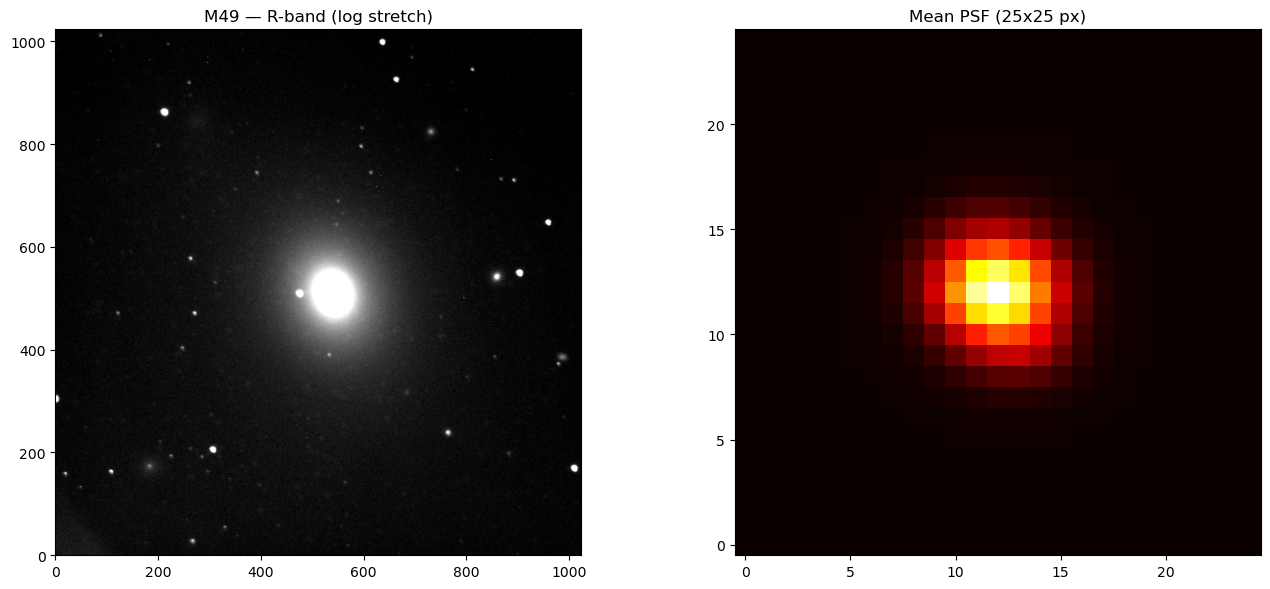

In [89]:
# Quick look
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

vmin = BG
vmax = BG + 20 * BG_STD

ax1.imshow(image.data, norm=LogNorm(vmin=vmin, vmax=vmax), cmap='gray')
ax1.set_title('M49 — R-band (log stretch)')

ax2.imshow(psf, cmap='hot')
ax2.set_title(f'Mean PSF ({psf.shape[0]}x{psf.shape[1]} px)')

plt.tight_layout()

## 2. Source detection and segmentation

PetroFit wraps `photutils` to detect sources and create a deblended segmentation map. We use this to locate M49 (largest source by area) and measure its morphology.

**Note**: For a galaxy this large (~50% of detector), the deblender may split it into multiple segments. We only use the catalog for centre/ellipticity estimation — not for masking, which would remove parts of the galaxy itself.

Deblending:   0%|          | 0/1 [00:00<?, ?it/s]

Detected 33 sources


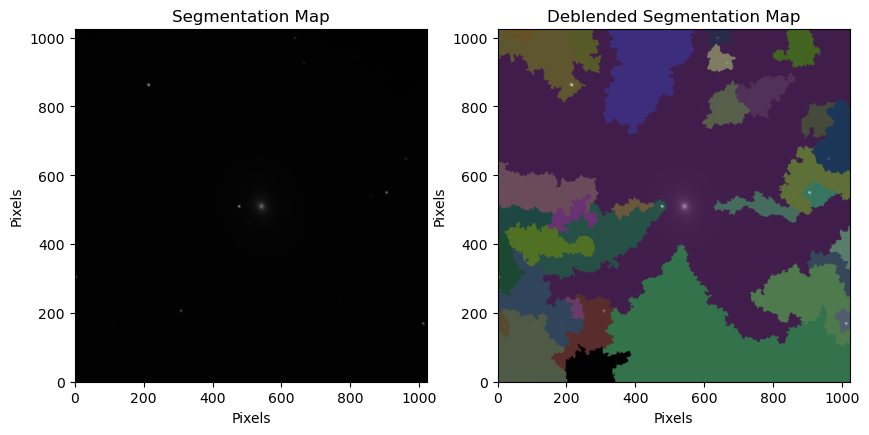

In [90]:
cat, segm, segm_deblend = pf.make_catalog(
    image.data,
    threshold=3 * BG_STD,
    deblend=True,
    npixels=10,
    plot=True,
)
print(f'Detected {len(cat)} sources')

In [91]:
# Select M49 as the largest source
sorted_idx = pf.order_cat(cat, key='area', reverse=True)
source = cat[sorted_idx[0]]

x0, y0 = pf.get_source_position(source)
ellip = pf.get_source_ellip(source)
theta = pf.get_source_theta(source)

print(f'M49 centre:    ({x0:.1f}, {y0:.1f}) px')
print(f'Ellipticity:   {ellip:.3f}')
print(f'Position angle: {np.degrees(theta):.1f} deg')
print(f'Source area:   {source.area.value:.0f} px  ({source.area.value / image.data.size * 100:.0f}% of detector)')

M49 centre:    (540.0, 509.0) px
Ellipticity:   0.178
Position angle: -12.6 deg
Source area:   480227 px  (46% of detector)


## 3. Why Petrosian photometry fails here

PetroFit normally uses Petrosian photometry (non-parametric growth curves) to estimate initial parameters. For **M49, this doesn't work** — the galaxy fills nearly half the detector, so we can never reach the Petrosian radius where the surface brightness drops to $\eta = 0.2$ of the mean.

This is a common problem with nearby giant ellipticals on small-format detectors. Instead, we provide initial guesses directly from the segmentation catalogue and our knowledge of the galaxy type.

## 4. 2D Sérsic model fitting

PetroFit fits a PSF-convolved 2D Sérsic model directly to the image pixels using `PSFConvolvedModel2D`.

$$I(r) = I_e \exp\left\{ -b_n \left[ \left(\frac{r}{r_e}\right)^{1/n} - 1 \right] \right\}$$

- $r_e$: effective (half-light) radius
- $n$: Sérsic index ($n=4$: de Vaucouleurs, $n=1$: exponential disk)
- $I_e$: surface brightness at $r_e$

Text(0.5, 1.0, 'M49 cutout (500x500 px, bg-subtracted)')

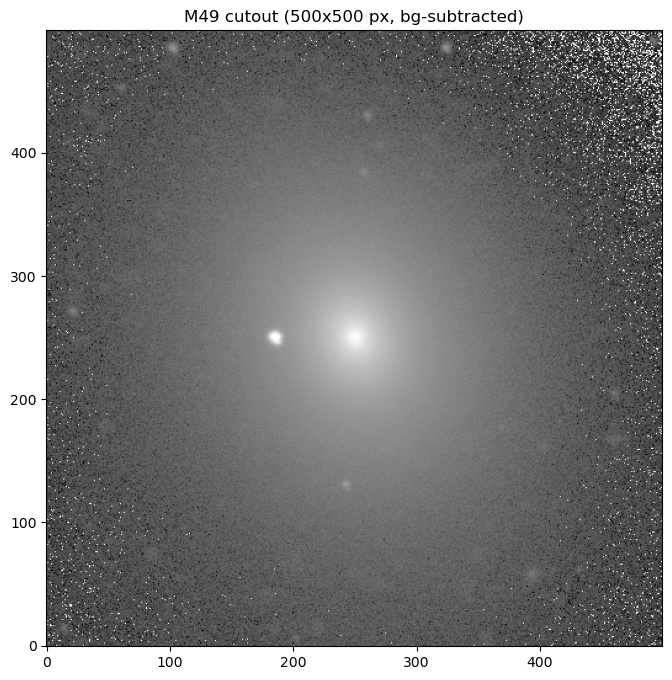

In [92]:
# Extract a cutout centred on M49
# We do NOT use pf.masked_segm_image here — for a galaxy filling half the
# detector, the deblender splits it into multiple segments, and the mask
# would remove large parts of the galaxy itself. Instead we fit the cutout
# directly; a few superimposed stars are negligible for the Sérsic fit.
cutout_size = 500

bg_sub = image.data - BG
cutout = Cutout2D(bg_sub, (x0, y0), cutout_size, mode='partial', copy=True)
cx, cy = cutout_size / 2, cutout_size / 2

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(cutout.data, norm=LogNorm(vmin=10, vmax=cutout.data.max()), cmap='gray')
ax.set_title(f'M49 cutout ({cutout_size}x{cutout_size} px, bg-subtracted)')

In [93]:
# Initial parameter estimates
# For a giant elliptical: start with n=4 (de Vaucouleurs)
# Estimate amplitude from the pixel value ~1 r_eff away from centre
r_eff_init = 40  # px (~30 arcsec — reasonable starting guess)
amp_init = cutout.data[int(cy), int(cx + r_eff_init)]

print('Initial guesses:')
print(f'  r_eff  = {r_eff_init} px ({r_eff_init * PLATE_SCALE:.0f}")')
print(f'  n      = 4.0 (de Vaucouleurs)')
print(f'  amp    = {amp_init:.0f} ADU/px')
print(f'  ellip  = {ellip:.3f}')
print(f'  theta  = {np.degrees(theta):.1f} deg')

Initial guesses:
  r_eff  = 40 px (31")
  n      = 4.0 (de Vaucouleurs)
  amp    = 2775 ADU/px
  ellip  = 0.178
  theta  = -12.6 deg


In [94]:
# Build PSF-convolved Sérsic model
sersic = models.Sersic2D(
    amplitude=amp_init,
    r_eff=r_eff_init,
    n=4.0,
    x_0=cx,
    y_0=cy,
    ellip=ellip,
    theta=theta,
    bounds=pf.get_default_sersic_bounds({
        'x_0': (cx - 20, cx + 20),
        'y_0': (cy - 20, cy + 20),
        'n': (0.5, 10),
        'r_eff': (5, 400),
    })
)

psf_model = pf.PSFConvolvedModel2D(sersic, psf=psf, oversample=4)
psf_model.fixed['psf_pa'] = True

print('Model before fitting:')
pf.print_model_params(psf_model)

Model before fitting:
2774.8462	amplitude
40.0000	r_eff
4.0000	n
250.0000	x_0
250.0000	y_0
0.1784	ellip
-0.2204	theta
0.0000	psf_pa


In [95]:
# Fit! The cutout is already background-subtracted.
fitted_model, fit_info = pf.fit_model(
    cutout.data,
    psf_model,
    calc_uncertainties=True,
    maxiter=10000,
    acc=1e-9,
)

print('Fitted parameters:')
pf.print_model_params(fitted_model)

Fitted parameters:
407.1265	amplitude
153.0458	r_eff
3.9492	n
250.5318	x_0
250.2208	y_0
0.1258	ellip
-1.1014	theta
0.0000	psf_pa


## 5. Visualise the fit: data / model / residual

Good residuals should look like noise — any remaining structure indicates the model is missing something (e.g., a disk component, dust lane, or tidal features).

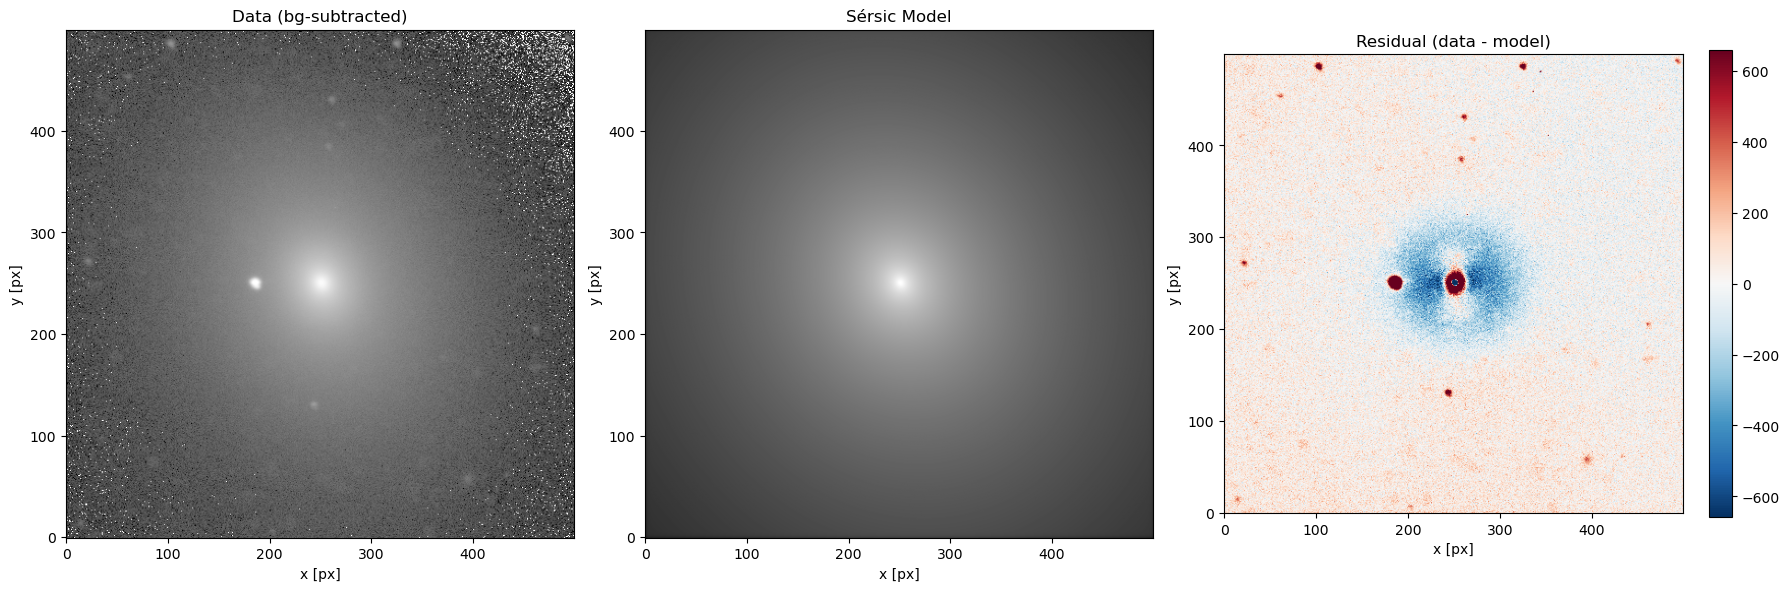

In [96]:
# Generate model image
ys, xs = np.mgrid[:cutout_size, :cutout_size]
model_image = fitted_model(xs, ys)
residual = cutout.data - model_image

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

vmin_log = 10
vmax_log = cutout.data.max()

ax1.imshow(cutout.data, norm=LogNorm(vmin=vmin_log, vmax=vmax_log), cmap='gray')
ax1.set_title('Data (bg-subtracted)')

ax2.imshow(model_image, norm=LogNorm(vmin=vmin_log, vmax=vmax_log), cmap='gray')
ax2.set_title('Sérsic Model')

im = ax3.imshow(residual, vmin=-5*BG_STD, vmax=5*BG_STD, cmap='RdBu_r')
ax3.set_title('Residual (data - model)')
plt.colorbar(im, ax=ax3, fraction=0.046)

for ax in (ax1, ax2, ax3):
    ax.set_xlabel('x [px]')
    ax.set_ylabel('y [px]')

plt.tight_layout()

## 6. Physical parameters for the Kormendy relation

In [97]:
# Extract fitted values
r_eff_px = fitted_model.r_eff.value
n = fitted_model.n.value
amp = fitted_model.amplitude.value  # I_e in ADU/px (bg-subtracted)
e = fitted_model.ellip.value
pa = np.degrees(fitted_model.theta.value)

# Convert to physical units
r_eff_arcsec = r_eff_px * PLATE_SCALE

# Surface brightness at r_eff:
# mu_e = -2.5 * log10(I_e [ADU/s/px]) + ZP + 2.5 * log10(pixel_area [arcsec^2])
pixel_area = PLATE_SCALE**2
mu_e = -2.5 * np.log10(amp / EXPTIME) + ZP + 2.5 * np.log10(pixel_area)

print('=' * 55)
print('  Sérsic fit results for M49 (NGC 4472)')
print('=' * 55)
print(f'  Sérsic index n    = {n:.2f}')
print(f'  r_eff             = {r_eff_px:.1f} px  =  {r_eff_arcsec:.1f}"')
print(f'  mu_e (R-band)     = {mu_e:.2f} mag/arcsec^2')
print(f'  Ellipticity       = {e:.3f}  (b/a = {1-e:.3f})')
print(f'  Position angle    = {pa:.1f} deg')
print('=' * 55)
print()
print('For the Kormendy relation:')
print(f'  log(r_e)  = {np.log10(r_eff_arcsec):.3f}  [arcsec]')
print(f'  mu_e      = {mu_e:.2f}  [mag/arcsec^2]')

  Sérsic fit results for M49 (NGC 4472)
  Sérsic index n    = 3.95
  r_eff             = 153.0 px  =  118.3"
  mu_e (R-band)     = 22.74 mag/arcsec^2
  Ellipticity       = 0.126  (b/a = 0.874)
  Position angle    = -63.1 deg

For the Kormendy relation:
  log(r_e)  = 2.073  [arcsec]
  mu_e      = 22.74  [mag/arcsec^2]


In [98]:
# Convert r_eff to physical size in kpc using the angular diameter distance
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u

cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# M49 (NGC 4472): recession velocity ~997 km/s (NED)
v_rec = 997 * u.km / u.s
z = (v_rec / cosmo.H0 / cosmo.hubble_distance).decompose().value  # Hubble-flow redshift

# For very nearby galaxies the Hubble flow distance is uncertain;
# the commonly adopted distance to M49 is ~16.7 Mpc (Tonry et al. 2001, SBF).
D = 16.7 * u.Mpc  # adopt SBF distance

# Angular diameter distance (for z << 1, D_A ~ D)
d_A = D
kpc_per_arcsec = d_A.to(u.kpc).value * np.radians(1 / 3600)

r_eff_kpc = r_eff_arcsec * kpc_per_arcsec

print(f'Distance:        {D:.1f} (SBF, Tonry et al. 2001)')
print(f'Scale:           {kpc_per_arcsec:.4f} kpc/arcsec')
print(f'r_eff:           {r_eff_arcsec:.1f}" = {r_eff_kpc:.2f} kpc')
print(f'log(r_e [kpc]):  {np.log10(r_eff_kpc):.3f}')

Distance:        16.7 Mpc (SBF, Tonry et al. 2001)
Scale:           0.0810 kpc/arcsec
r_eff:           118.3" = 9.58 kpc
log(r_e [kpc]):  0.981


## 7. Isophote fitting with `photutils.isophote`

Non-parametric isophote fitting (equivalent to IRAF `ellipse`). This fits elliptical isophotes directly — no assumed profile shape — and gives radial profiles of surface brightness, ellipticity, position angle, and higher-order Fourier terms (B4 for boxy/disky classification).

In [99]:
from photutils.isophote import Ellipse, EllipseGeometry

geometry = EllipseGeometry(
    x0=x0, y0=y0,
    sma=10,
    eps=e,
    pa=fitted_model.theta.value,
)

ellipse = Ellipse(image.data - BG, geometry)
isolist = ellipse.fit_image(maxsma=300, step=0.1, linear=False)

print(f'Fitted {len(isolist)} isophotes')
print(f'SMA range: {isolist.sma.min():.1f} - {isolist.sma.max():.1f} px')

Fitted 68 isophotes
SMA range: 0.0 - 281.0 px


In [100]:
# Surface brightness profiles: isophotes vs Sérsic model
from scipy.special import gammaincinv

# Isophote SB
good = isolist.intens > 0
sma_arcsec = isolist.sma[good] * PLATE_SCALE
mu_iso = -2.5 * np.log10(isolist.intens[good] / EXPTIME) + ZP + 2.5 * np.log10(pixel_area)

# Sérsic model SB
r_model = np.linspace(0.5, 300, 500)
bn = gammaincinv(2 * n, 0.5)
sb_model = amp * np.exp(-bn * ((r_model / r_eff_px)**(1/n) - 1))
r_arcsec_model = r_model * PLATE_SCALE
mu_model = -2.5 * np.log10(sb_model / EXPTIME) + ZP + 2.5 * np.log10(pixel_area)

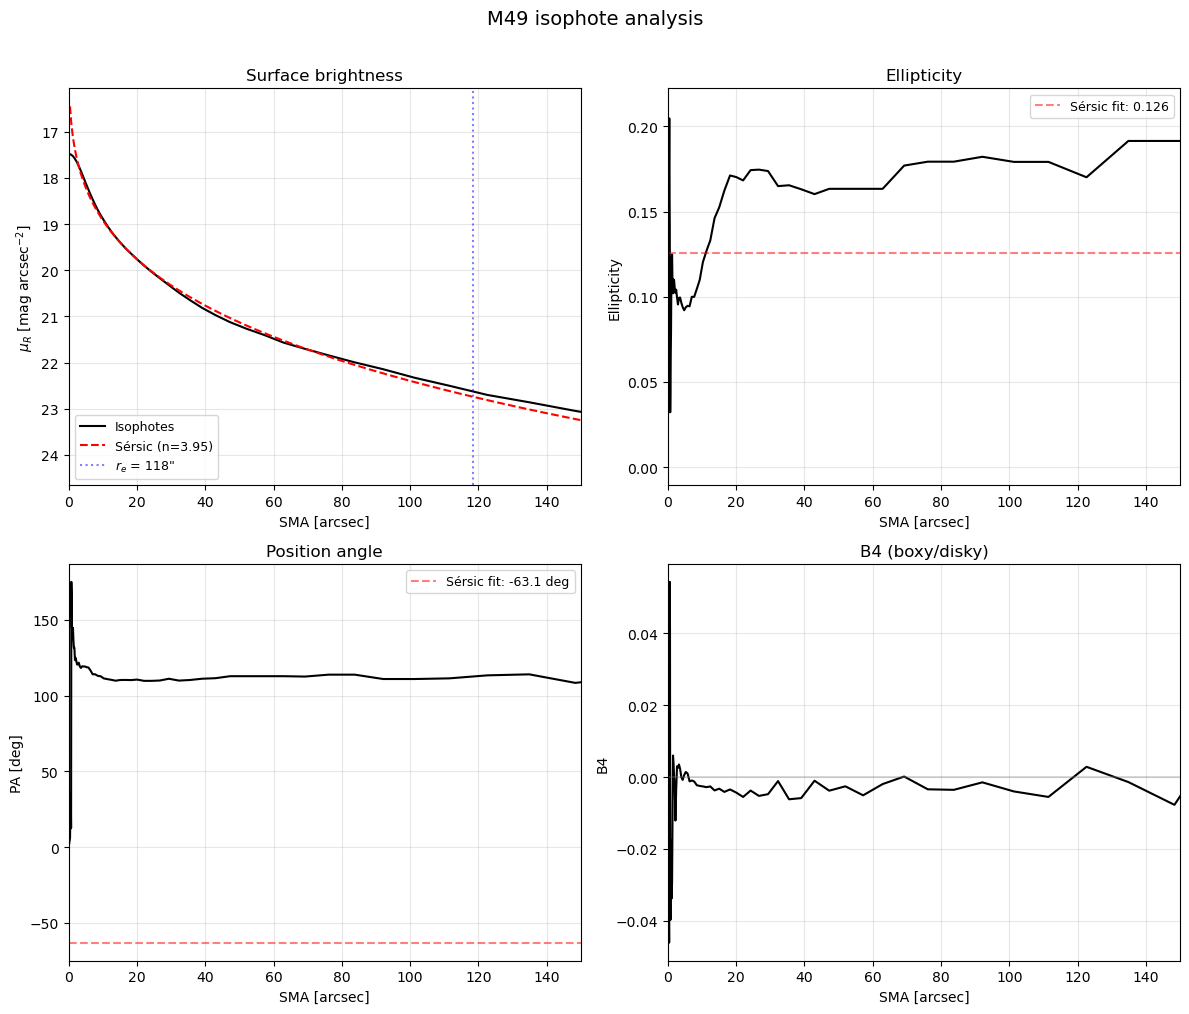

In [101]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Surface brightness profile
ax = axes[0, 0]
ax.plot(sma_arcsec, mu_iso, 'k-', lw=1.5, label='Isophotes')
ax.plot(r_arcsec_model, mu_model, 'r--', lw=1.5, label=f'Sérsic (n={n:.2f})')
ax.axvline(r_eff_arcsec, color='blue', ls=':', alpha=0.5, label=f'$r_e$ = {r_eff_arcsec:.0f}"')
ax.invert_yaxis()
ax.set_xlabel('SMA [arcsec]')
ax.set_ylabel(r'$\mu_R$ [mag arcsec$^{-2}$]')
ax.set_title('Surface brightness')
ax.legend(fontsize=9)
ax.set_xlim(0, 150)
ax.grid(True, alpha=0.3)

# Ellipticity profile
ax = axes[0, 1]
ax.plot(isolist.sma * PLATE_SCALE, isolist.eps, 'k-', lw=1.5)
ax.axhline(e, color='red', ls='--', alpha=0.5, label=f'Sérsic fit: {e:.3f}')
ax.set_xlabel('SMA [arcsec]')
ax.set_ylabel('Ellipticity')
ax.set_title('Ellipticity')
ax.legend(fontsize=9)
ax.set_xlim(0, 150)
ax.grid(True, alpha=0.3)

# Position angle profile
ax = axes[1, 0]
ax.plot(isolist.sma * PLATE_SCALE, np.degrees(isolist.pa), 'k-', lw=1.5)
ax.axhline(pa, color='red', ls='--', alpha=0.5, label=f'Sérsic fit: {pa:.1f} deg')
ax.set_xlabel('SMA [arcsec]')
ax.set_ylabel('PA [deg]')
ax.set_title('Position angle')
ax.legend(fontsize=9)
ax.set_xlim(0, 150)
ax.grid(True, alpha=0.3)

# B4 coefficient: boxy (< 0) vs disky (> 0)
ax = axes[1, 1]
ax.plot(isolist.sma * PLATE_SCALE, isolist.b4, 'k-', lw=1.5)
ax.axhline(0, color='gray', ls='-', alpha=0.3)
ax.set_xlabel('SMA [arcsec]')
ax.set_ylabel('B4')
ax.set_title('B4 (boxy/disky)')
ax.set_xlim(0, 150)
ax.grid(True, alpha=0.3)

plt.suptitle('M49 isophote analysis', fontsize=14, y=1.01)
plt.tight_layout()

## 8. Radial profile: data vs model

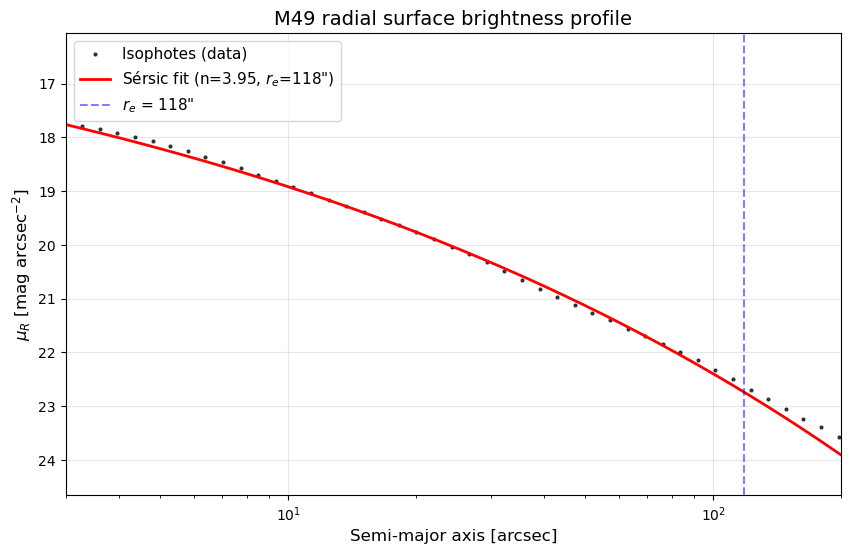

In [102]:
fig, ax = plt.subplots(figsize=(10, 6))

# Isophote data
ax.plot(sma_arcsec, mu_iso, 'k.', ms=4, alpha=0.7, label='Isophotes (data)')

# Sérsic model
ax.plot(r_arcsec_model, mu_model, 'r-', lw=2,
        label=f'Sérsic fit (n={n:.2f}, $r_e$={r_eff_arcsec:.0f}")')

ax.axvline(r_eff_arcsec, color='blue', ls='--', alpha=0.5, label=f'$r_e$ = {r_eff_arcsec:.0f}"')

ax.set_xlabel('Semi-major axis [arcsec]', fontsize=12)
ax.set_ylabel(r'$\mu_R$ [mag arcsec$^{-2}$]', fontsize=12)
ax.set_title('M49 radial surface brightness profile', fontsize=14)
ax.invert_yaxis()
ax.set_xscale('log')
ax.legend(fontsize=11)
ax.set_xlim(3, 200)
ax.grid(True, alpha=0.3)

## 9. Comparison with HST/ACS (space vs ground)

The ACSVCS survey (Côté et al. 2004, program 9401) observed M49 with HST/ACS in F475W (~SDSS g). The ACS/WFC pixel scale is 0.05"/px — 15x finer than OHP T120. The cutout covers the central ~50" of the galaxy, where the ground-based profile is most affected by seeing.

Since F475W and R-band have different zeropoints, we shift the HST profile vertically to match the OHP profile in the overlap region. This lets us compare the **shape** of the profiles: the key difference is in the core, where HST resolves the flat "core" typical of giant ellipticals while the OHP profile is rounded by atmospheric seeing.

In [103]:
# Load HST/ACS F475W cutout (1024x1024 at 0.05"/px = 51" across)
# Downloaded from the HLA fitscut service: ACSVCS program 9401
HST_FILE = os.path.join(DATA_DIR, 'NGC4472_HST_F475W.fits')

hst_hdu = fits.open(HST_FILE)
hst_data = hst_hdu[0].data.copy()
hst_hdr = hst_hdu[0].header

PS_HST = np.sqrt(hst_hdr['CD1_1']**2 + hst_hdr['CD2_1']**2) * 3600  # arcsec/px
PHOTFLAM = hst_hdr['PHOTFLAM']
HST_PHOTZPT = hst_hdr['PHOTZPT']  # STmag system

print(f'HST image:    {hst_data.shape}')
print(f'Pixel scale:  {PS_HST:.4f} arcsec/px (vs OHP: {PLATE_SCALE} arcsec/px)')
print(f'FOV:          {hst_data.shape[0] * PS_HST:.0f} arcsec')
print(f'Units:        {hst_hdr.get("BUNIT", "?")}')
print(f'Resolution:   15x finer than OHP')

# Replace NaN pixels (chip gap) with background
hst_corners = np.concatenate([hst_data[:30,:30].ravel(), hst_data[:30,-30:].ravel(),
                              hst_data[-30:,:30].ravel(), hst_data[-30:,-30:].ravel()])
_, hst_bg, _ = sigma_clipped_stats(hst_corners[~np.isnan(hst_corners)], sigma=3)
hst_nan = np.isnan(hst_data)
hst_data[hst_nan] = hst_bg
hst_sub = hst_data - hst_bg

# Find galaxy centre in HST image
from scipy.ndimage import gaussian_filter
hst_smooth = gaussian_filter(hst_sub, sigma=10)
hst_cy, hst_cx = np.unravel_index(hst_smooth.argmax(), hst_smooth.shape)
print(f'Galaxy centre: ({hst_cx}, {hst_cy})')

HST image:    (1024, 1024)
Pixel scale:  0.0500 arcsec/px (vs OHP: 0.773 arcsec/px)
FOV:          51 arcsec
Units:        ELECTRONS/S
Resolution:   15x finer than OHP
Galaxy centre: (516, 506)


In [104]:
# HST radial surface brightness profile (circular annuli)
Y_hst, X_hst = np.mgrid[:hst_sub.shape[0], :hst_sub.shape[1]]
R_hst = np.sqrt((X_hst - hst_cx)**2 + (Y_hst - hst_cy)**2)

r_edges_hst = np.logspace(np.log10(1), np.log10(450), 60)
r_mid_hst = 0.5 * (r_edges_hst[:-1] + r_edges_hst[1:])
sb_hst = np.full(len(r_mid_hst), np.nan)

for i in range(len(r_mid_hst)):
    mask = (R_hst >= r_edges_hst[i]) & (R_hst < r_edges_hst[i+1]) & (~hst_nan)
    if mask.sum() > 10:
        sb_hst[i] = np.median(hst_sub[mask])

# Convert to STmag surface brightness
hst_good = sb_hst > 0
r_arcsec_hst = r_mid_hst[hst_good] * PS_HST
zp_st = -2.5 * np.log10(PHOTFLAM) + HST_PHOTZPT
mu_hst = -2.5 * np.log10(sb_hst[hst_good]) + zp_st + 2.5 * np.log10(PS_HST**2)

# Shift HST profile to match OHP in the overlap region (10-20 arcsec)
overlap = (r_arcsec_hst > 10) & (r_arcsec_hst < 20)
ohp_overlap = (sma_arcsec > 10) & (sma_arcsec < 20)
if overlap.sum() > 3 and ohp_overlap.sum() > 3:
    offset = np.median(mu_iso[ohp_overlap]) - np.median(mu_hst[overlap])
    print(f'Colour offset (F475W → R): {offset:+.2f} mag (applied as vertical shift)')
else:
    offset = 0
mu_hst_shifted = mu_hst + offset

print(f'HST profile: {hst_good.sum()} radial bins, {r_arcsec_hst.min():.1f}-{r_arcsec_hst.max():.1f} arcsec')

Colour offset (F475W → R): +0.21 mag (applied as vertical shift)
HST profile: 45 radial bins, 0.2-21.4 arcsec


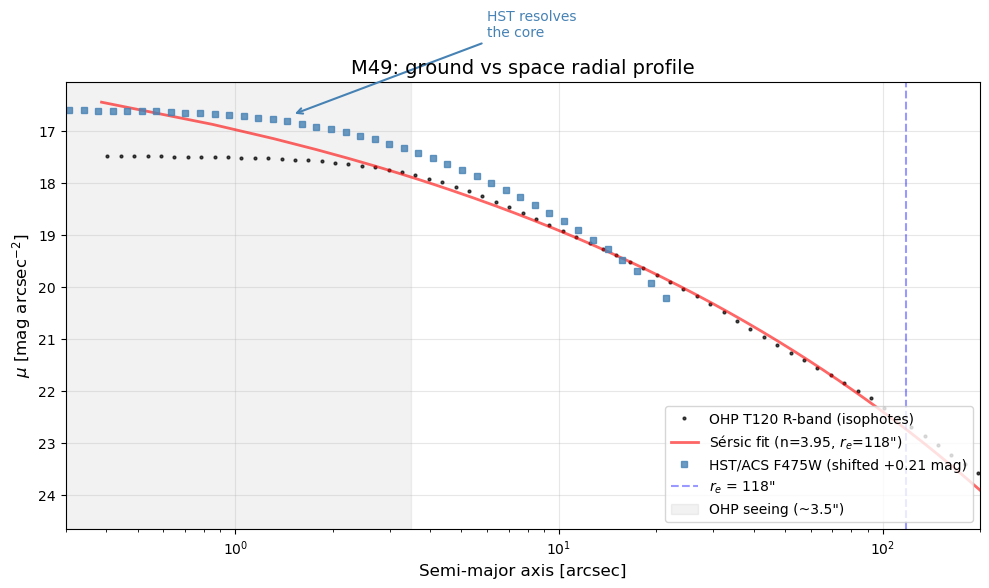

In [105]:
fig, ax = plt.subplots(figsize=(10, 6))

# OHP isophote profile
ax.plot(sma_arcsec, mu_iso, 'k.', ms=4, alpha=0.7, label='OHP T120 R-band (isophotes)')

# OHP Sérsic model
ax.plot(r_arcsec_model, mu_model, 'r-', lw=2, alpha=0.6,
        label=f'Sérsic fit (n={n:.2f}, $r_e$={r_eff_arcsec:.0f}")')

# HST profile (shifted to match OHP)
ax.plot(r_arcsec_hst, mu_hst_shifted, 's', color='steelblue', ms=5, alpha=0.8,
        label=f'HST/ACS F475W (shifted {offset:+.2f} mag)')

ax.axvline(r_eff_arcsec, color='blue', ls='--', alpha=0.4, label=f'$r_e$ = {r_eff_arcsec:.0f}"')

# Mark the seeing limit
FWHM_OHP = 3.5  # typical OHP seeing in arcsec
ax.axvspan(0, FWHM_OHP, color='gray', alpha=0.1, label=f'OHP seeing (~{FWHM_OHP}")')

ax.set_xlabel('Semi-major axis [arcsec]', fontsize=12)
ax.set_ylabel(r'$\mu$ [mag arcsec$^{-2}$]', fontsize=12)
ax.set_title('M49: ground vs space radial profile', fontsize=14)
ax.invert_yaxis()
ax.set_xscale('log')
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim(0.3, 200)
ax.grid(True, alpha=0.3)

ax.annotate('HST resolves\nthe core', xy=(1.5, mu_hst_shifted[r_arcsec_hst < 2].mean()),
            xytext=(6, mu_hst_shifted[r_arcsec_hst < 2].mean() - 1.5),
            fontsize=10, color='steelblue',
            arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.5))

plt.tight_layout()

## 9. Comparison with literature

| Parameter | This work (R) | VEGAS g (1) | VEGAS i (1) | KFCB V (2) |
|-----------|------------:|------------:|------------:|-----------:|
| r_e [arcsec] | 118 | 152 ± 6 | 152 ± 7 | — |
| r_e [kpc] | 9.6 | 12.5 | 12.5 | — |
| $\mu_e$ [mag/arcsec²] | 22.74 | 22.52 ± 0.05 | 21.25 ± 0.05 | — |
| n | 3.95 | ~4 | ~4 | 5.99 |

(1) Capaccioli et al. 2015, A&A 581, A10 — VEGAS/VST deep imaging, D = 16.9 Mpc  
(2) Kormendy et al. 2009, ApJS 182, 216 — different fitting range and core treatment

Our $\mu_e$ = 22.74 (R-band) sits between the VEGAS g (22.52) and i (21.25) values, as expected from the (g−R) and (R−i) colours of an old stellar population.

Our $r_e$ = 118" is ~25% smaller than the VEGAS value of 152". This is expected: the VEGAS data reaches ~10 $r_e$ with a 1° FOV, while our T120 image covers only ~400" from the galaxy centre. Fitting a truncated profile biases $r_e$ low — a limitation to note when working with small-format detectors.

### For a Kormendy relation project:
- Repeat for each galaxy in your sample
- Collect $(\log r_e, \mu_e)$ from the Sérsic fits
- Plot: $\mu_e = a + b \cdot \log r_e$ and fit a linear relation
- Literature slope: $b \approx 3$ mag/dex

In [106]:
# Final summary
print('Results for Kormendy relation:')
print(f'  Galaxy:           M49 (NGC 4472)')
print(f'  Distance:         {D:.1f}')
print(f'  Filter:           R-band')
print(f'  Sérsic index:     n = {n:.2f}')
print(f'  Effective radius: r_e = {r_eff_arcsec:.1f}" = {r_eff_kpc:.2f} kpc')
print(f'  mu_e:             {mu_e:.2f} mag/arcsec^2')
print(f'  log(r_e [kpc]):   {np.log10(r_eff_kpc):.3f}')
print(f'  Ellipticity:      {e:.3f}')
print(f'  PA:               {pa:.1f} deg')

Results for Kormendy relation:
  Galaxy:           M49 (NGC 4472)
  Distance:         16.7 Mpc
  Filter:           R-band
  Sérsic index:     n = 3.95
  Effective radius: r_e = 118.3" = 9.58 kpc
  mu_e:             22.74 mag/arcsec^2
  log(r_e [kpc]):   0.981
  Ellipticity:      0.126
  PA:               -63.1 deg
